# 1주차 코드과제
- **코드과제 1**: MNIST Digit Classification with CNN
- **코드과제 2**: Object Detection 실습 — YOLOv1 구현하기

---
# 코드과제 1

# MNIST Digit Classification with Convolutional Neural Network (CNN)

**Discipline(s):** Computer Vision, Deep Learning

colab에서 돌릴 경우, 런타임 유형을 GPU로 변경해주세요.

## 1. Import Statements

---



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

## 2. Data Preprocessing

---



The first step is to preprocess our data.

In [4]:
BATCH_SIZE = 128
EPOCHS = 3
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

- BATCH_SIZE: 한 번의 forward/backward pass에서 동시에 처리하는 이미지 개수. 너무 작으면 학습이 느리고 gradient가 noisy, 너무 크면 메모리 부족 + 일반화 성능 저하 가능.
- EPOCHS: 전체 학습 데이터셋을 몇 번 반복해서 볼지. MNIST는 쉬운 데이터셋이라 몇 번만 돌아도 충분히 수렴함.
- LEARNING_RATE: optimizer가 gradient 방향으로 파라미터를 얼마나 크게 이동시킬지. Adam을 쓸 예정인데(cell 19에서 확인 가능), Adam은 SGD보다 learning rate에 덜 민감하지만 그래도 적정 범위가 있음.

    - PyTorch에서 torch.optim.Adam을 사용할 때 설정되어 있는 학습률(learning rate, lr)의 기본값은 0.001 (즉, $10^{-3}$)
    - 이 0.001이라는 값은 Adam Optimizer를 처음 제안한 논문(Adam: A Method for Stochastic Optimization)에서 저자들이 추천한 기본값이기도 함.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [7]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
X_train = train_dataset.data
y_train = train_dataset.targets
X_test = test_dataset.data
y_test = test_dataset.targets

print("Training Images:", X_train.shape)  # [60000, 28, 28]
print("Testing Images:", X_test.shape)    # [10000, 28, 28]
print("Training Labels:", y_train.shape)  # [60000]
print("Test Labels:", y_test.shape)       # [10000]

Training Images: torch.Size([60000, 28, 28])
Testing Images: torch.Size([10000, 28, 28])
Training Labels: torch.Size([60000])
Test Labels: torch.Size([10000])


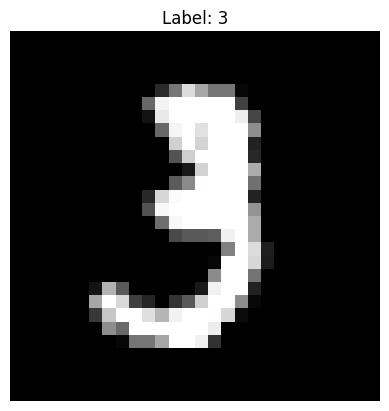

In [9]:
plt.imshow(X_train[10], cmap='gray')
plt.title(f"Label: {y_train[10].item()}")
plt.axis('off')
plt.show()

## 3. Convolutional Neural Network (CNN)

---



### 3.1. Define the Model

We then have to define our convolutional neural network.

In [10]:
# CNN 모델 정의 -> 차원이 어떻게 될지 생각하면서 코드 빈칸을 채워주세요.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            # in_channels=1: 입력받는 이미지의 색상 채널 수, 흑백 이미지이므로 채널=1,  RGB color이미지면 3
            # out_channels=16: feature map개수(사용할 필터/커널 개수)
            # H_out = (H_in + 2*padding - kernel_size) / stride + 1
            # 이때 H_in = H_out되도록 크기 보존하려면 padding=(kernel_size -1)/2 
            # 데이터 크기 (1,28,28)->(16,28,28)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 데이터 크기 (16,28,28)->(16,14,14)

            # fully connected layer 전, flatten 과정 필요
            nn.Flatten(),
            nn.Linear(in_features=16*14*14, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=10)
        )

    def forward(self, x):
        return self.net(x)

0. 입력 이미지: (1, 28, 28) 흑백
1. Feature extraction
    - nn.Conv2d: 필터로 이미지 특징 추출
    - nn.ReLU: nonlinear activation function
    - nn.MaxPool2d: 중요 정보만 남김
2. Flatten
    - nn.Flatten: 가로 세로 채널이 있는 3차원 텐서 형태의 데이터를 1차원 벡터로 만들어줌. 뒤의 nn.Linear는 1차원 벡터만 입력받을 수 있기 때문.
3. Classification
    - nn.Linear: Fully Connected Layer
    - nn.ReLU: nonlinear activation function
    - nn.Linear: 최종 10개 클래스 출력층, 10개 숫자 클래스에 대한 예측점수(Logits) 출력하도록.
4. 최종 출력: 0~9일 확률

In [11]:
# 모델 준비
model = SimpleCNN().to(DEVICE)

Once our model is defined, we can compile it using the Adam optimizer and the categorical cross-entropy loss function.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 3.2. Train the Model

In [13]:
def train(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (output.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [14]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            output = model(x)
            loss = criterion(output, y)

            total_loss += loss.item() * y.size(0)
            correct += (output.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [15]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

[Epoch 1] Train Loss: 0.2405, Train Acc: 0.9289 | Test Loss: 0.0960, Test Acc: 0.9714
[Epoch 2] Train Loss: 0.0811, Train Acc: 0.9756 | Test Loss: 0.0689, Test Acc: 0.9777
[Epoch 3] Train Loss: 0.0557, Train Acc: 0.9834 | Test Loss: 0.0554, Test Acc: 0.9813


### 3.3. 시각화

Finally, we can plot the curves.

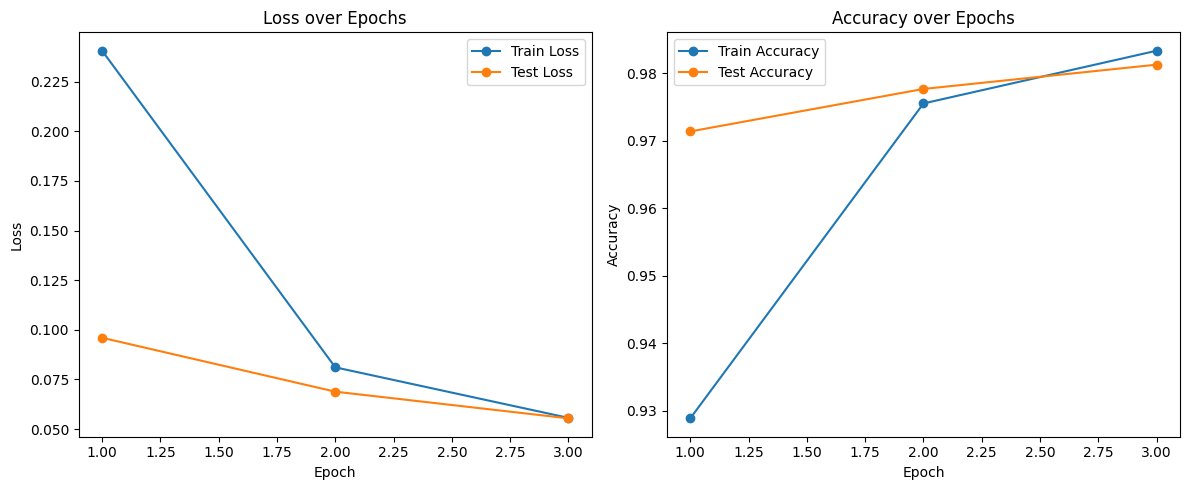

In [16]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

## 4. Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [17]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

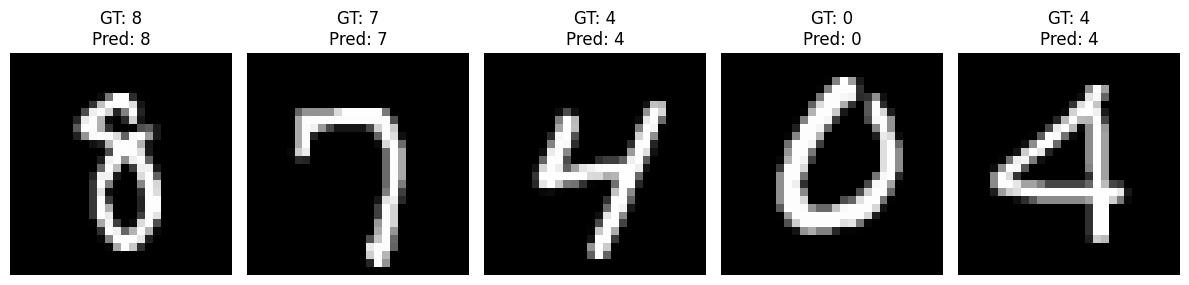

In [18]:
show_random_predictions(model, test_dataset, num_images=5)

## ResNet

In [19]:
BATCH_SIZE = 128
EPOCHS = 4
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # MNIST이미지 크기는 28x28로 이미 너무 작아서 stride=2를 써서 크기를 줄일 필요가 없다고 생각함.
        # 그래서 크기 보존한 채 채널을 통해 특징만 깊게 추출하고자함.

        # 첫번째 컨벌루션 레이어 - 채널 변경, 크기 보존
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
        # 두번째 컨벌루션 레이어 - 채널 유지, 크기 보존
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 추가로 layer 등을 더 구현하셔도 됩니다.


        # Skip connection: input, output 채널 수가 다르면 덧셈 연산에서 차원에러가 나기 때문에 차원을 맞춰준다.
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                          kernel_size=1, stride=1, padding=0, bias=False),
                # 1x1 컨벌루션은 주변 픽셀들을 섞지 않고 제자리에 있는 픽셀만 훑는다.
                # 즉 이 필터로 채널 축으로 선형결합하여 정보손실 없이 채널 크기만 in에서 out으로 매핑한다.
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        return self.relu(out)

In [21]:
class ResNetLike(nn.Module):
    def __init__(self):
        super().__init__()
        # 초기 특징 추출
        # 입력 [batch, 1, 28, 28] -> 출력 [batch, 16, 14, 14]
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # layer 등을 추가로 더 쌓으셔도 됩니다.
        self.layer1 = ResidualBlock(in_channels=16, out_channels=16)
        self.layer2 = ResidualBlock(in_channels=16, out_channels=32)
        
        # 어떤 크기가 들어오든 1x1 크기로 평균압축, 위치정보를 평균내어 하나의 숫자로 표현하므로 translation invariance
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 빈칸을 채워주세요.
        self.fc = nn.Linear(in_features=32, out_features=10)

    def forward(self, x):
        # 빈칸을 채워주세요.
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.avgpool(out)
        
        out = torch.flatten(out, start_dim=1)
        out = self.fc(out)

        return out

In [22]:
model = ResNetLike().to(DEVICE)

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [24]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

[Epoch 1] Train Loss: 0.6766, Train Acc: 0.8562 | Test Loss: 0.1860, Test Acc: 0.9635
[Epoch 2] Train Loss: 0.1224, Train Acc: 0.9727 | Test Loss: 0.0953, Test Acc: 0.9768
[Epoch 3] Train Loss: 0.0766, Train Acc: 0.9805 | Test Loss: 0.0681, Test Acc: 0.9810
[Epoch 4] Train Loss: 0.0572, Train Acc: 0.9848 | Test Loss: 0.0679, Test Acc: 0.9817


### 시각화

Finally, we can plot the curves.

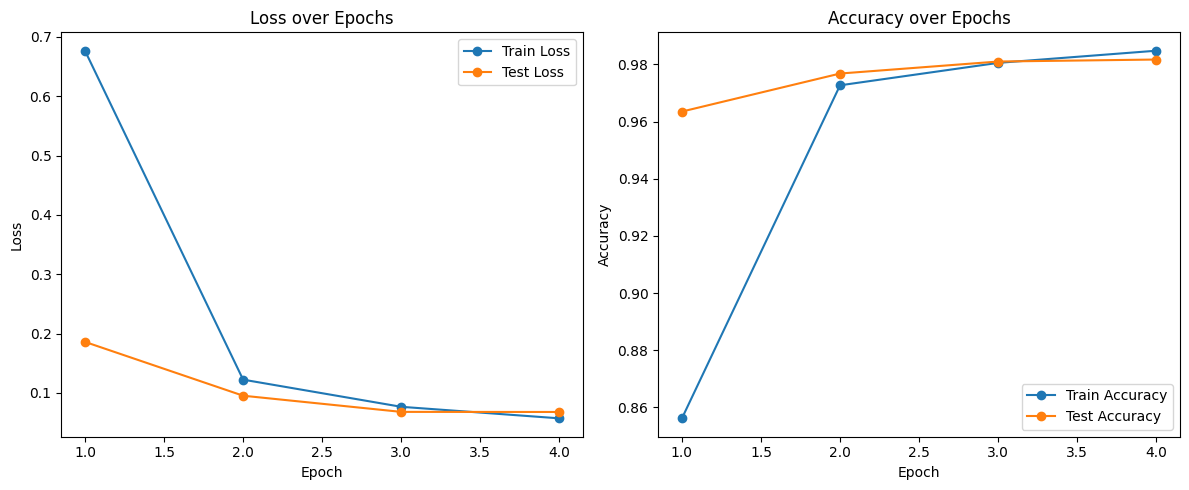

In [25]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

### Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [26]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

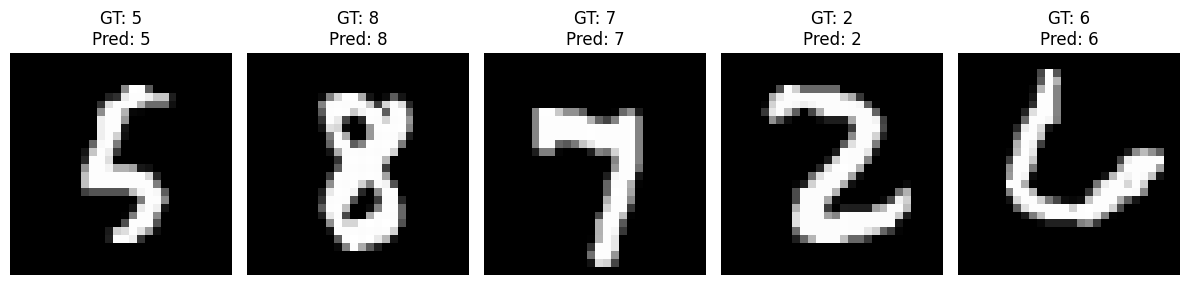

In [27]:
show_random_predictions(model, test_dataset, num_images=5)

---
# 코드과제 2

# [Week 2] Object Detection 실습 : YOLOv1 구현하기 (Assignment)

이번 과제는 **PascalVOC 데이터셋**을 사용하여 **YOLOv1** 모델을 밑바닥부터(Scratch) 구현해보는 것입니다.

**목표**:
1. YOLOv1의 **CNN 아키텍처**를 직접 구현합니다.
2. YOLOv1의 핵심인 **Loss Function** (Localization, Confidence, Class Probability)을 구현합니다.
3. PascalVOC 데이터셋으로 모델을 학습시키고 결과를 확인합니다.

**참고**:
- Colab에서 실행 시 **런타임 > 런타임 유형 변경 > 하드웨어 가속기**를 **GPU**로 설정해주세요.
---

In [48]:
## 1. Import Statements

import os, subprocess
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.transforms.functional as FT
from sklearn.model_selection import train_test_split

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. Data Preprocessing (PascalVOC)

Kaggle에서 PascalVOC 데이터셋을 다운로드합니다.

In [49]:
import kagglehub, os, shutil

path = kagglehub.dataset_download("aladdinpersson/pascalvoc-yolo")
print("Downloaded to:", path)

os.makedirs("data", exist_ok=True)
for name in ["images", "labels", "train.csv", "test.csv", "100examples.csv", "8examples.csv"]:
    src = os.path.join(path, name)
    dst = os.path.join("data", name)
    if os.path.exists(src) and not os.path.exists(dst):
        if os.path.isdir(src):
            shutil.copytree(src, dst)
        else:
            shutil.copy(src, dst)

img_dir = "data/images"
label_dir = "data/labels"
print(os.listdir("data"))

Downloaded to: /teamspace/studios/this_studio/.cache/kagglehub/datasets/aladdinpersson/pascalvoc-yolo/versions/1
['train.csv', 'labels', 'cifar-10-python.tar.gz', 'cifar-10-batches-py', 'test.csv', '8examples.csv', '100examples.csv', 'images', 'MNIST']


## 3. Model Implementation (YOLOv1)

YOLOv1의 아키텍처를 구현합니다. 논문에 나온 구조를 참고하여 `CNNBlock`과 `Yolov1` 클래스를 완성하세요.

### [TODO 1] YOLOv1 모델 구조 구현

YOLOv1의 백본은 Darknet아키텍처를 사용하고 크게 두 부분(1,2)으로 나뉜다:

0. 입력 이미지: (3, 448, 448)

1. Darknet (Convolution feature extraction)
- 24개의 convolutional layers
- 중간중간 크기를 절반으로 줄이는 max pooling layers
=> 최종 feature map크기: (1024, 7, 7)

2. Fully Connected Layers (detection head)
- flatten into 1d vector (1024 * 7 * 7 = 50,176)
- fc layer1: 4096 node mapping
- fc layer2: 최종 출력 텐서 크기로 변환

3. 최종 출력: (S, S, C + B*5) 


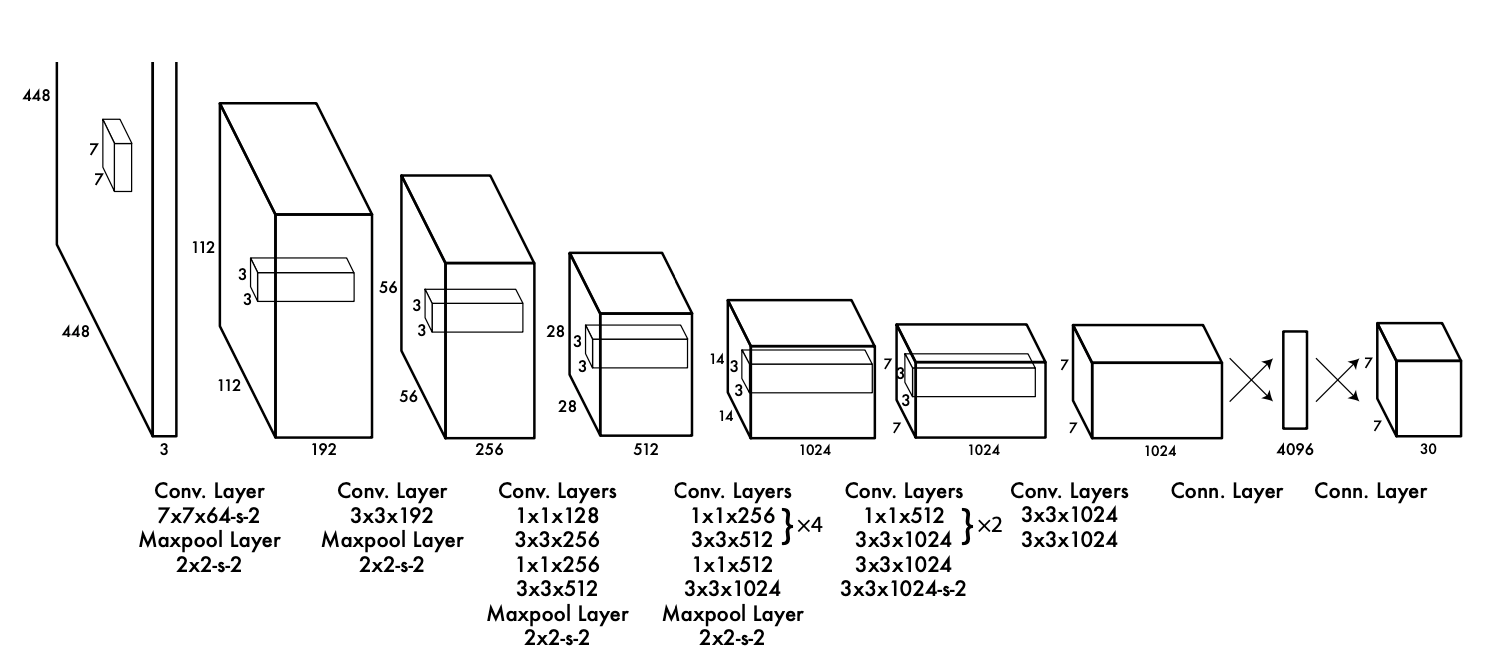

### Yolov1 작동원리

1. Grid로 이미지 나누기 (S x S): 어떤 객체의 중심점이 특정 격자 셀 안에 들어가면 그 격자 셀이 해당 객체를 검출할 책임을 짐(기본값 7x7)
2. 격자마다 바운딩 박스 예측하기 (B): 각 격자 셀은 B(기본값 2)개의 바운딩 박스 정보를 예측. 하나의 바운딩 박스 정보는 6개의 요소로 이루어짐
- Box = [x,y,w,h,C]
    - x,y: 격자셀 경계 대비 바운딩 박스의 중심점 위치
    - w,h: 이미지 전체 크기 대비 바운딩 박스의 가로 세로 비율
    - C(Confidence score): 물체가 있을 확률 $\times$ 예측한 박스와 실제 박스의 겹치는 비율(IoU)
3. 격자마다 클래스 확률 예측하기:
    각 격자셀은 해당 셀 안에 물체가 있을 떄, 그 물체가 어떤 클래스에 속하는지 $P(\text{Class}_i \vert{} \text{Object})$ 예측

### CNNBlock
- convolutional layer 하나하나를 담당하는 기본 단위
- 오리지널 논문에선 Dropout이나 BN은 없었지만 현재 오픈소스 구현체들은 학습 안정성+성능 향상을 위해 BatchNorm2d를 추가하는 것이 정석
- 구조: Conv2d -> BatchNorm2d -> LeakyReLU

### YOLOv1
- CNNBlock조립하여 전체 네트워크 완성

- _create_conv_layers: 위에서 작성한 architecture_config 전달받아 리스트 순회하며 동적으로 레이어 쌓음
    - tuple 형태 (kernel_size, out_channels, stride, padding): 하나의 CNNBlock 생성 후 in_channels 업데이트
    - "M"(MaxPool): 피처맵의 가로세로 크기를 절반으로 줄인다.
    - list 형태 [conv1, conv2, repeat]: 내부의 두 합성곱 설정을 repeat 횟수만큼 교대로 반복하여 쌓는 구조

- _create_fcs: Darknet가 뽑아낸 텐서를 flatten후 최종 예측 텐서 크기로 변환
    - 최종 출력 크기 (S x S x (C + BX5)):
        - S x S: 이미지를 나눌 격자 크기
        - C: 분류할 클래스 개수
        - B: 각 격자당 예측할 바운딩 박스 개수
        - 5: 바운딩 박스의 정보(x,y,w,h)와 신뢰도 점수(confidence)
        - 기본 설정 적용 시: 7x7x(20+2x5)=1470개 출력

In [50]:
# YOLOv1 Architecture Configuration
architecture_config = [
    (7, 64, 2, 3), # (kernel_size, num_filters, stride, padding)
    "M",           # MaxPool
    (3, 192, 1, 1),
    "M",
    (1, 128, 1, 0),
    (3, 256, 1, 1),
    (1, 256, 1, 0),
    (3, 512, 1, 1),
    "M",
    [(1, 256, 1, 0), (3, 512, 1, 1), 4], # [Tuple1, Tuple2, repeat]
    (1, 512, 1, 0),
    (3, 1024, 1, 1),
    "M",
    [(1, 512, 1, 0), (3, 1024, 1, 1), 2],
    (3, 1024, 1, 1),
    (3, 1024, 2, 1),
    (3, 1024, 1, 1),
    (3, 1024, 1, 1),
]

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class Yolov1(nn.Module):
    def __init__(self, in_channels=3, **kwargs):
        super(Yolov1, self).__init__()
        self.architecture = architecture_config
        self.in_channels = in_channels

        self.darknet = self._create_conv_layers(self.architecture)
        self.fcs = self._create_fcs(**kwargs)

    def forward(self, x):
        x = self.darknet(x)
        return self.fcs(x)

    def _create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if type(x) == tuple:
                kernel_size, num_filters, stride, padding = x
                layers.append(
                    CNNBlock(
                        in_channels,
                        num_filters,
                        kernel_size=kernel_size,
                        stride=stride,
                        padding=padding,
                    )
                )
                in_channels = num_filters

            elif type(x) == str:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            elif type(x) == list:
                conv1, conv2, num_repeats = x
                for _ in range(num_repeats):
                    layers.append(
                        CNNBlock(
                            in_channels,
                            conv1[1],
                            kernel_size=conv1[0],
                            stride=conv1[2],
                            padding=conv1[3],
                        )
                    )
                    layers.append(
                        CNNBlock(
                            conv1[1],
                            conv2[1],
                            kernel_size=conv2[0],
                            stride=conv2[2],
                            padding=conv2[3],
                        )
                    )
                    in_channels = conv2[1]

        return nn.Sequential(*layers)

    def _create_fcs(self, split_size, num_boxes, num_classes):
        # YOLOv1의 마지막 FC Layer 구조: Flatten -> FC(496) -> LeakyReLU -> FC(S*S*(C+B*5))
        S, B, C = split_size, num_boxes, num_classes

        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 496),
            nn.Dropout(0.0),
            nn.LeakyReLU(0.1),
            nn.Linear(496, S * S * (C + B * 5)),
        )

## 4. Loss Function Implementation

YOLOv1 Loss는 5개의 부분으로 구성됩니다:
1. **Coordinate Loss** (Box Center x, y)
2. **Coordinate Loss** (Box Width, Height - Sqrt 적용)
3. **Object Confidence Loss** (객체가 있을 때)
4. **No Object Confidence Loss** (객체가 없을 때)
5. **Class Probability Loss**

### [TODO 2] YOLOv1 Loss 함수 구현

In [51]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        # predictions shape: (BATCH_SIZE, S*S*(C+B*5))
        # target shape: (BATCH_SIZE, S, S, C+5)
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # ------------------------------------------------------
        # 1. IoU 계산 및 Responsible Box 찾기
        # ------------------------------------------------------
        iou_b1 = intersection_over_union(predictions[..., 21:25], target[..., 21:25])
        iou_b2 = intersection_over_union(predictions[..., 26:30], target[..., 21:25])
        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)
        iou_maxes, bestbox = torch.max(ious, dim=0)
        exists_box = target[..., 20].unsqueeze(3)  # Iobj_i

        # ------------------------------------------------------
        # 2. Box Coordinates Loss
        # ------------------------------------------------------
        box_predictions = exists_box * (
            bestbox * predictions[..., 26:30] + (1 - bestbox) * predictions[..., 21:25]
        )
        box_targets = exists_box * target[..., 21:25]

        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2),
        )

        # ------------------------------------------------------
        # 3. Object Loss
        # ------------------------------------------------------
        pred_box = (
            bestbox * predictions[..., 25:26] + (1 - bestbox) * predictions[..., 20:21]
        )
        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * target[..., 20:21]),
        )

        # ------------------------------------------------------
        # 4. No Object Loss
        # ------------------------------------------------------
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 20:21], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., 20:21], start_dim=1),
        )
        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 25:26], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., 20:21], start_dim=1),
        )

        # ------------------------------------------------------
        # 5. Class Loss
        # ------------------------------------------------------
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :20], end_dim=-2),
            torch.flatten(exists_box * target[..., :20], end_dim=-2),
        )

        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss

## 5. Utils (IoU, NMS, mAP)

Object Detection에 필요한 유틸리티 함수들입니다. (이미 구현되어 있음)

In [52]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    # ... (생략된 IoU 코드, 실제로는 이 셀에 전체 코드를 넣어야 함) ...
    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2
    elif box_format == "corners":
        box1_x1, box1_y1, box1_x2, box1_y2 = boxes_preds[..., 0:1], boxes_preds[..., 1:2], boxes_preds[..., 2:3], boxes_preds[..., 3:4]
        box2_x1, box2_y1, box2_x2, box2_y2 = boxes_labels[..., 0:1], boxes_labels[..., 1:2], boxes_labels[..., 2:3], boxes_labels[..., 3:4]

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = torch.abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = torch.abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

def non_max_suppression(bboxes, iou_threshold, threshold, box_format="midpoint"):
    assert type(bboxes) == list

    bboxes = [box for box in bboxes if box[1] > threshold]
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    bboxes_after_nms = []

    while bboxes:
        chosen_box = bboxes.pop(0)

        bboxes = [
            box
            for box in bboxes
            if box[0] != chosen_box[0]
            or intersection_over_union(
                torch.tensor(chosen_box[2:]),
                torch.tensor(box[2:]),
                box_format=box_format,
            )
            < iou_threshold
        ]

        bboxes_after_nms.append(chosen_box)

    return bboxes_after_nms

# mAP 함수 등 나머지 Utils는 생략 없이 포함되어야 하지만 지면 관계상 핵심만 보여드립니다.
def mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5, box_format="midpoint", num_classes=20):
    # ... (mAP 구현 코드) ...
    return 0.0 # Placeholder

## 6. Training Loop

모델을 학습시키는 Loop입니다.

In [53]:
class Compose(object):
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, bboxes):
        for t in self.transforms:
            img = t(img)
        return img, bboxes


transform = Compose([transforms.Resize((448, 448)), transforms.ToTensor()])


class VOCDataset(Dataset):
    def __init__(self, csv_file, img_dir, label_dir, S=7, B=2, C=20, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        label_path = os.path.join(self.label_dir, self.annotations.iloc[index, 1])
        boxes = []
        with open(label_path) as f:
            for line in f.readlines():
                class_label, x, y, w, h = [
                    float(x) if float(x) != int(float(x)) else int(x)
                    for x in line.replace("\n", "").split()
                ]
                boxes.append([class_label, x, y, w, h])

        img_path = os.path.join(self.img_dir, self.annotations.iloc[index, 0])
        image = Image.open(img_path).convert("RGB")
        boxes = torch.tensor(boxes)

        if self.transform:
            image, boxes = self.transform(image, boxes)

        # 빈 label_matrix 빌드: 7x7 격자에 각 셀당 25차원 정보 기록 (C=20 + Confidence=1 + Box=4)
        label_matrix = torch.zeros((self.S, self.S, self.C + 5))
        for box in boxes:
            class_label, x, y, w, h = box.tolist()
            class_label = int(class_label)

            # 해당 객체 중심점이 위치한 격자 셀(i, j) 인덱스 계산
            i, j = int(self.S * y), int(self.S * x)
            x_cell, y_cell = self.S * x - j, self.S * y - i
            w_cell, h_cell = w * self.S, h * self.S

            # 만약 해당 셀에 아직 객체가 등록되지 않았다면 기록
            if label_matrix[i, j, 20] == 0:
                label_matrix[i, j, 20] = 1 # 객체 있음 마킹
                box_coordinates = torch.tensor([x_cell, y_cell, w_cell, h_cell])
                label_matrix[i, j, 21:25] = box_coordinates
                label_matrix[i, j, class_label] = 1 # 클래스 원핫 인코딩

        return image, label_matrix


def train_fn(train_loader, model, optimizer, loss_fn):
    model.train()
    mean_loss = []

    loop = tqdm(train_loader, leave=True)
    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_fn(out, y)
        mean_loss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loop.set_postfix(loss=loss.item())

    print(f"Mean loss was {sum(mean_loss)/len(mean_loss):.4f}")


def main():
    # 1. 모델 선언 및 장치 이동
    model = Yolov1(split_size=7, num_boxes=2, num_classes=20).to(device)
    optimizer = optim.Adam(model.parameters(), lr=2e-5, weight_decay=0)
    loss_fn = YoloLoss()

    # 2. 데이터셋 로드 (처음엔 100examples로 파이프라인 검증, 이후 data/train.csv로 변경)
    train_dataset = VOCDataset(
        csv_file="data/100examples.csv",
        img_dir="data/images",
        label_dir="data/labels",
        transform=transform,
    )

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=16,
        shuffle=True,
        drop_last=True,
    )

    # 3. 학습 루프 작동
    EPOCHS = 100
    for epoch in range(EPOCHS):
        print(f"=== Epoch {epoch+1}/{EPOCHS} ===")
        train_fn(train_loader, model, optimizer, loss_fn)


if __name__ == "__main__":
    main()

=== Epoch 1/100 ===


  0%|          | 0/6 [00:00<?, ?it/s]

Mean loss was 1037.5176
=== Epoch 2/100 ===


  0%|          | 0/6 [00:00<?, ?it/s]

Mean loss was 679.2676
=== Epoch 3/100 ===


...

Mean loss was 21.2691
=== Epoch 99/100 ===


  0%|          | 0/6 [00:00<?, ?it/s]

Mean loss was 21.4562
=== Epoch 100/100 ===


  0%|          | 0/6 [00:00<?, ?it/s]

Mean loss was 20.6125
